# HEST coverage95 external benchmark readiness

This notebook summarizes the external-method benchmark readiness audit for the high-confidence HEST human Visium coverage95 target. It checks current assets, method source availability, dependency gaps, and adapter priority before running any external baseline.

## Scope

The audit covers the same 234 high-confidence train/val/test slides used by the current coverage95 expression run. It does not report external model performance. Its purpose is to decide which method can be adapted first under a fair benchmark contract: same slide split, same coverage95 target genes, same spot order, and the unified evaluator from the formal benchmark harness.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

CWD = Path.cwd()
ROOT = CWD if (CWD / "configs").exists() else CWD.parent
OUT = ROOT / "results" / "hest1k_human_visium_expression" / "external_benchmark_readiness"

required = [
    OUT / "run_summary.json",
    OUT / "slide_assets.csv",
    OUT / "input_manifest.csv",
    OUT / "method_readiness.csv",
    OUT / "adapter_priority.csv",
]
missing = [str(path.relative_to(ROOT)) for path in required if not path.exists()]
assert not missing, missing

summary = json.loads((OUT / "run_summary.json").read_text(encoding="utf-8"))
slide_assets = pd.read_csv(OUT / "slide_assets.csv")
readiness = pd.read_csv(OUT / "method_readiness.csv")
priority = pd.read_csv(OUT / "adapter_priority.csv")

display(Markdown(f"Audited slides: **{summary['n_slides']}**"))
display(pd.DataFrame([summary["slide_asset_summary"]]).T.rename(columns={0: "all_selected_slides"}))

Audited slides: **234**

,all_selected_slides
raw_h5ad_all,True
patch_h5_all,True
patch_h5_img_all,True
thumbnail_all,True
wsi_all,False


In [2]:
asset_cols = [
    "raw_st_exists", "raw_patches_exists", "patch_h5_has_img", "patch_h5_has_barcode",
    "patch_h5_has_coords", "raw_thumbnail_exists", "raw_wsi_exists",
    "processed_features_exists", "processed_counts_exists", "processed_coords_exists",
]
asset_summary = slide_assets.groupby("split")[asset_cols].agg(["sum", "count"])
display(asset_summary)

mismatch = slide_assets[slide_assets["n_spots_manifest"] != slide_assets["patch_h5_n_img"]][
    ["sample_id", "split", "organ", "n_spots_manifest", "patch_h5_n_img", "measured_target_genes"]
]
display(Markdown(f"Slides where manifest n_spots differs from patch-H5 image count: **{len(mismatch)}**"))
display(mismatch.head(20))

raw_st_exists       raw_patches_exists       patch_h5_has_img        \
                sum count                sum count              sum count   
split                                                                       
test             48    48                 48    48               48    48   
train           163   163                163   163              163   163   
val              23    23                 23    23               23    23   

      patch_h5_has_barcode       patch_h5_has_coords        \
                       sum count                 sum count   
split                                                        
test                    48    48                  48    48   
train                  163   163                 163   163   
val                     23    23                  23    23   

      raw_thumbnail_exists       raw_wsi_exists        \
                       sum count            sum count   
split                                                   
test                    48    48              0    48   
train                  163   163              0   163   
val                     23    23              0    23   

      processed_features_exists       processed_counts_exists        \
                            sum count                     sum count   
split                                                                 
test                         48    48                      48    48   
train                       163   163                     163   163   
val                          23    23                      23    23   

      processed_coords_exists        
                          sum count  
split                                
test                       48    48  
train                     163   163  
val                        23    23

Slides where manifest n_spots differs from patch-H5 image count: **201**

,sample_id,split,organ,n_spots_manifest,patch_h5_n_img,measured_target_genes
1,MISC34,train,Bowel,3731,3705,16874
2,MISC35,val,Bowel,3578,3525,16689
3,MISC36,train,Bowel,3502,3476,16743
4,MISC37,train,Bowel,3636,3552,16939
5,MISC38,train,Bowel,1727,1709,16933
6,MISC39,train,Bowel,4078,4064,16847
7,MISC40,train,Bowel,4116,4102,16928
8,MISC41,train,Bowel,3708,3638,16829
9,MISC42,train,Bowel,659,643,16897
10,MISC43,train,Bowel,1186,1181,16735


## Method readiness

`patch_h5_adapter_ready` means the original source exists and the current HEST assets contain enough patch-level RGB data to replace the original WSI-crop reader. It does not mean the external method has already been run. Original workflows that require WSI remain blocked in their unmodified form because WSI files are not present.

,method,adapter_priority,adapter_status,patch_h5_adapter_possible,original_requires_wsi,key_files_present,key_files_total,pretrained_files_present,pretrained_files_total,missing_python_modules,blockers
0,HisToGene,1,patch_h5_adapter_ready,True,True,4,4,0,0,NaN,original_workflow_missing_wsi
1,THItoGene,2,patch_h5_adapter_ready,True,True,4,4,0,0,NaN,original_workflow_missing_wsi
2,mclSTExp,3,patch_h5_adapter_ready_missing_environment,True,False,4,4,0,0,timm,missing_python_modules:timm
3,HiST,4,blocked_or_needs_nontrivial_adapter,False,True,3,3,1,1,timm,missing_python_modules:timm|original_workflow_...
4,iStar,5,blocked_or_needs_nontrivial_adapter,False,True,4,4,2,2,NaN,original_workflow_missing_wsi
5,sCellST,6,patch_h5_adapter_ready,True,False,2,2,0,0,NaN,NaN


,adapter_status,n_methods
0,blocked_or_needs_nontrivial_adapter,2
1,patch_h5_adapter_ready,3
2,patch_h5_adapter_ready_missing_environment,1


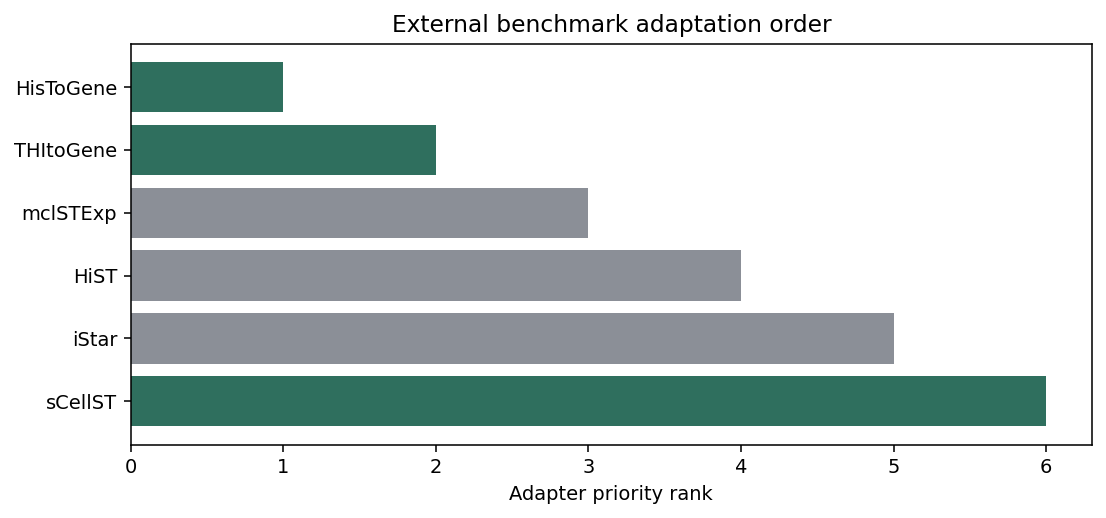

In [3]:
display_cols = [
    "method", "adapter_priority", "adapter_status", "patch_h5_adapter_possible",
    "original_requires_wsi", "key_files_present", "key_files_total",
    "pretrained_files_present", "pretrained_files_total", "missing_python_modules", "blockers",
]
display(readiness[display_cols])

grouped = readiness.groupby("adapter_status").size().reset_index(name="n_methods")
display(grouped)

fig, ax = plt.subplots(figsize=(8, 3.8), dpi=140)
plot_df = readiness.sort_values("adapter_priority")
colors = plot_df["adapter_status"].map({
    "patch_h5_adapter_ready": "#2f6f5e",
    "blocked_or_needs_nontrivial_adapter": "#8b8f97",
}).fillna("#8b8f97")
ax.barh(plot_df["method"], plot_df["adapter_priority"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Adapter priority rank")
ax.set_title("External benchmark adaptation order")
fig.tight_layout()
plt.show()

## Adapter priority decision

The first external baseline to implement should be HisToGene with a patch-H5 dataset adapter. The reason is practical: the method is a direct supervised image-to-expression baseline, its core source files are present, required Python modules are available in the current environment, and every selected HEST slide has `patches/{sample_id}.h5` with `img`, `barcode`, and `coords` datasets.

The original HisToGene WSI-crop workflow is still blocked because WSI files are absent, so the adapter must read HEST patch H5 images and align by barcode/processed spot order. THItoGene is next, but its whole-slide graph batches are heavier. HiST and iStar should wait until either WSI assets are available or a deeper feature-level adapter is written.

In [4]:
display(priority[["method", "adapter_priority", "adapter_status", "blockers", "first_adapter_reason"]])

first = priority.sort_values("adapter_priority").iloc[0]
assert first["method"] == "HisToGene"
assert first["adapter_status"] == "patch_h5_adapter_ready"
assert summary["slide_asset_summary"]["patch_h5_img_all"] is True
assert summary["slide_asset_summary"]["wsi_all"] is False

,method,adapter_priority,adapter_status,blockers,first_adapter_reason
0,HisToGene,1,patch_h5_adapter_ready,original_workflow_missing_wsi,Simplest image-patch supervised baseline; orig...
1,THItoGene,2,patch_h5_adapter_ready,original_workflow_missing_wsi,"Patch-H5 adapter is feasible, but whole-slide ..."
2,mclSTExp,3,patch_h5_adapter_ready_missing_environment,missing_python_modules:timm,"Can use HEST patch images, but contrastive tra..."
3,HiST,4,blocked_or_needs_nontrivial_adapter,missing_python_modules:timm|original_workflow_...,"Pretrained cTransPath file is present, but ori..."
4,iStar,5,blocked_or_needs_nontrivial_adapter,original_workflow_missing_wsi,"DINO checkpoints are present, but the method d..."
5,sCellST,6,patch_h5_adapter_ready,NaN,Separate framework and configs; useful after d...


## Next implementation step

Implement `HisToGenePatchH5Dataset` inside the HistoOmniST workspace, using the committed coverage95 target gene list and the external benchmark input manifest. The dataset should emit spot-level patch tensors, normalized grid coordinates, and expression targets in the same spot order expected by the unified benchmark evaluator. Training outputs and prediction arrays should remain under ignored `results/` or `checkpoints/`; only adapter code and executed audit notebooks should be committed.